---
title: EOPF Jupyter Notebook Template
subtitle: Learn how to use the EOPF Jupyter Notebook template
authors:
  - name: Anne Fouilloux
    orcid: 0000-0002-1784-2920
    github: annefou
    affiliations:
      - id: Simula Research Laboratory
        institution: Simula Research Laboratory
        ror: 00vn06n10
  - name: Deyan Samardzhiev
    github: sunnydean
    orcid: 0009-0003-3803-8522
    affiliations:
      - id: Lampata UK
        institution: Lampata UK
date: 2025-01-29
thumbnail: https://raw.githubusercontent.com/EOPF-Sample-Service/eopf-sample-notebooks/refs/heads/main/notebooks/static/ESA_logo_2020_Deep.png
keywords: ["earth observation", "remote sensing"]
tags: ["stac"]
releaseDate: 2025-01-29
datePublished: 2025-01-29
dateModified: 2025-06-10
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of contents

```{contents}
:depth: 1
```

(Introduction)=
## Introduction

We will use the STAC API to search for and retrieve Sentinel-2 L2A data to generate burn severity maps for assessing areas affected by wildfires.


### Methodology approach
* Access Sentinel-2 L2A cloud optimised dataset through STAC
* Compute the Normalised Burn Ratio (NBR) index to highlight burned areas
* Classify burn severity


## Data
We will use Sentinel-2 L2A data in EOPF Zarr format, accessing it via STAC to identify burned areas, inspect them in more detail, and generate burn severity maps for assessing wildfire-affected regions.


#### Related publications
* https://www.sciencedirect.com/science/article/pii/S1470160X22004708#f0035
* https://github.com/yobimania/dea-notebooks/blob/e0ca59f437395f7c9becca74badcf8c49da6ee90/Fire%20Analysis%20Compiled%20Scripts%20(Gadi)/dNBR_full.py

:::{hint} Overview
**Questions**
- How can we use STAC to find and analyze Sentinel-2 data for wildfire assessment?
-  How can burn severity be mapped efficiently using satellite imagery?

**Objectives**
- Access and retrieve Sentinel-2 L2A data in EOPF Zarr format via STAC for wildfire-affected regions.
- Compute the Normalized Burn Ratio (NBR) and classify burn severity to produce actionable maps for post-fire assessment.
:::

(Setup)=
## Setup
Start importing the necessary libraries

In [40]:
from datetime import datetime
from datetime import timedelta

import numpy as np
import geopandas as gpd

from distributed import LocalCluster

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import shapely

from pystac_client import Client as pystac_client
from odc.stac import stac_load

import os
import xrlint.all as xrl

from xcube.core.verify import assert_cube

# Create and startup your Dask Cluster

Create Local Dask Cluster to access and process the data in parallel.

In [5]:
cluster = LocalCluster()
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 10.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42129,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34287,Total threads: 1
Dashboard: http://127.0.0.1:38461/status,Memory: 2.50 GiB
Nanny: tcp://127.0.0.1:35553,


(Read-EOPF-Zarr)=
## Read EOPF Zarr
We will now fetch the data using pystac to search through the earth-search.aws.element84.com/v1 STAC API endpoint. As mentioned in the [STAC and Data Access guide](../earthcode101/stac_and_data_access.ipynb), the STAC API provides us with endpoints to query STAC collections.

There is an ecosystem of libraries that implement STAC standards (pystac, odc-stac, stackstac, etc..) that allow us to analyse, load and use data described in STAC. We will briefly explore in the following cells below.

As a first step, we will open a catalog with the pystac library: https://earth-search.aws.element84.com/v1 This catalog contains STAC collections of various datasets (such as sentinel-1 and sentinel-2 data) in cloud optimised formats (COGs in this case) - see https://earth-search.aws.element84.com. for more details. With these formats we are able to use the assets using cloud-native access patterns (see https://guide.cloudnativegeo.org/cookbooks/ for more details).

Note that a STAC endpoint like the one below, only returns STAC items and not the actual data. The STAC items returned have Assets defined which link to the actual data (and provide metadata).

In [6]:
catalog = pystac_client.open("https://earth-search.aws.element84.com/v1")
chunk = {}  # <-- use dask
res = 10  # 10m resolution

# Analysing in Detail
Now that we have an idea of a potential wildfire event, we can explore in a bit more detail to see what areas where affected most. 

We will use higher resolution sentinel-2-l2a data to compute the Normalised Burn Ratio (NBR) index to highlight burned areas. The NBR index uses near-infrared (NIR) and shortwave-infrared (SWIR) wavelengths. We will use a STAC API [element84's STAC API](https://element84.com/earth-search/) endpoint to search for the data and load only the relevant, cloud-free data.

To estimate the amount of burnt area we will compute the difference between the NBR from period before the fire date and the NBR from the period after. The first step is to select the week before and the week after the wildfire

In [11]:
date_max_fire = "2020-09-13"
fire_date_t = datetime.strptime(date_max_fire, "%Y-%m-%d")

week_before = fire_date_t - timedelta(days=7)
week_after = fire_date_t + timedelta(days=7)

week_before, week_after

(datetime.datetime(2020, 9, 6, 0, 0), datetime.datetime(2020, 9, 20, 0, 0))

In [13]:
bbox = [-7.875, 41.625, -8.375, 41.875]

In the next step we will do two things:

**1.** Search for multiple cloudless sentinel-2 satellite images within a month of our pre-fire (week_before) date. The STAC API allows us to do a couple of things in a simple API call:
- We can define an arrea of interest (bbox) and search for items that cover this region
- We can subset for the time of interest as well (datetime)
- We can define custom querries over implemented STAC extensions. For example, the Sentinel STAC collection we are querrying implements the eo STAC extension, and defines cloud_cover - this allows us to search for quality assets with minimal cloudy pixels

This will return the relevant STAC items - which contain assets that point to our data of interest. We now need to load this data into a dataarray to start analysing it.

**2.** Note that in the above step, we only have items that point to some data - this data can be tiff, zarr, netcdf, COG, or other SpatioTemporal asset data. In our case, the element84 endpoint points to the data collection of  *https://registry.opendata.aws/sentinel-2-l2a-cogs/* - the format of our data is cloud-optimized GeoTiff. A cloud-friendly format such as this enables us cloud-native access patterns, such as easily fetching only our area of interest (as opposed to several tiff files and manually subsetting them after downloading).

Libraries such as odc-stac integrate with STAC standards and allow us to load data as well as leveraging the cloud-optimised formats. For example, in the cell below we define how we want to transform/load our data by:
- Passing the STAC item (or multiple items) we want to load
- defining a particular chunk size (the passed {} asks for the data to be automatically chunked as it is originally);
- We can request only the spectral bands of interest, in this case nir and swir22, to reduce the amount of data that we fetch.
- We can define a resolution to retrieve the data at, note that this will also resample automatically. For example the nir band data has a 10m resolution, but the swir22 - 20m resolution.
- There are multiple other options as well, such as defining in which projection we want our data in. More information can be found at: https://odc-stac.readthedocs.io/en/latest/_api/odc.stac.load.html


In [14]:
# STAC search for relevant items


week_before_start = week_before - timedelta(days=30)
time_range_start = str(week_before_start.date()) + "/" + str(week_before.date())

query1 = catalog.search(
    collections=["sentinel-2-l2a"],
    datetime=time_range_start,
    limit=100,
    bbox=bbox,
    query={"eo:cloud_cover": {"lt": 20}},
)

items = list(query1.items())
print(f"Found: {len(items):d} datasets")

Found: 13 datasets


In [15]:
# plot all the STAC assets
poly_pre = gpd.GeoSeries(
    [shapely.Polygon(item.geometry["coordinates"][0]) for item in items],
    name="geometry",
    crs="epsg:4236",
)
poly_pre.explore()

In [16]:
prefire_ds = stac_load(
    items,
    bands=("nir", "swir22"),
    chunks=chunk,  # <-- use Dask
    resolution=res,
    crs="EPSG:32629",
    groupby="datetime",
    bbox=bbox,
)
prefire_ds = prefire_ds.mean(dim="time")
prefire_ds

<xarray.Dataset> Size: 189MB
Dimensions:      (y: 2818, x: 4186)
Coordinates:
  * y            (y) float64 23kB 4.637e+06 4.636e+06 ... 4.608e+06 4.608e+06
  * x            (x) float64 33kB 5.519e+05 5.519e+05 ... 5.937e+05 5.937e+05
    spatial_ref  int32 4B 32629
Data variables:
    nir          (y, x) float64 94MB dask.array<chunksize=(2818, 4186), meta=np.ndarray>
    swir22       (y, x) float64 94MB dask.array<chunksize=(2818, 4186), meta=np.ndarray>

We now do the same for the month after..

In [17]:
week_after_end = week_after + timedelta(days=30)
time_range_end = str(week_after.date()) + "/" + str(week_after_end.date())

query2 = catalog.search(
    collections=["sentinel-2-l2a"],
    datetime=time_range_end,
    limit=100,
    bbox=bbox,
    query={"eo:cloud_cover": {"lt": 20}},
)

items = list(query2.items())
print(f"Found: {len(items):d} datasets")

Found: 8 datasets


In [18]:
poly_post = gpd.GeoSeries(
    [shapely.Polygon(item.geometry["coordinates"][0]) for item in items],
    name="geometry",
    crs="epsg:4236",
)
poly_post.explore()

In [19]:
postfire_ds = stac_load(
    items,
    bands=("nir", "swir22"),
    chunks=chunk,  # <-- use Dask
    resolution=res,
    crs="EPSG:32629",
    groupby="datetime",
    bbox=bbox,
)
postfire_ds = postfire_ds.mean(dim="time")
postfire_ds

<xarray.Dataset> Size: 189MB
Dimensions:      (y: 2818, x: 4186)
Coordinates:
  * y            (y) float64 23kB 4.637e+06 4.636e+06 ... 4.608e+06 4.608e+06
  * x            (x) float64 33kB 5.519e+05 5.519e+05 ... 5.937e+05 5.937e+05
    spatial_ref  int32 4B 32629
Data variables:
    nir          (y, x) float64 94MB dask.array<chunksize=(2818, 4186), meta=np.ndarray>
    swir22       (y, x) float64 94MB dask.array<chunksize=(2818, 4186), meta=np.ndarray>

In [20]:
max_poly_pre = poly_pre[[poly_pre.to_crs(epsg=3035).area.argmax()]]
max_poly_post = poly_post[[poly_post.to_crs(epsg=3035).area.argmax()]]

In [21]:
# note we're reprojecting to calculate area, as Geometry is in a geographic CRS. Results from 'area' are incorrect since geopandas doesn't calc spherical geometry!
poly_pre.area

/tmp/ipykernel_534/4246389161.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poly_pre.area


0     1.270576
1     1.271427
2     1.137933
3     1.142630
4     1.264818
5     1.268189
6     1.134230
7     1.134522
8     1.139294
9     1.143787
10    1.267352
11    1.268840
12    1.269646
dtype: float64

In [22]:
m = max_poly_pre.explore()
m = max_poly_post.explore(m=m, color="r")
m

> **Note:** The above STAC API query might return assets that intersect the region but do not fully cover it. I.e. if we fetched only one asset for each period with the above query they could potentially point to different regions (as there would be data missing). Although not relevant in this example, as all assets from both pre and after overlap, this will be a problem if not checked (as you'd be analysing different regions). In this example we visually inspect the overlap between assets and further take the mean of all the assets to get better quality pixels across time. Rerun the same example with cloud_cover = 0.2 to see where you might get some problem code!

# Calculating the NBR index

In the next step we will calculate our index, using simple band math as explained in the [xarray 101 guide](../pangeo101/xarray101.ipynb). We first define a function that calculates our index given a dataset with nir/swir22 band data and then add the additional variable to our pre-fire/post-fire datasets

In [23]:
index_name = "NBR"


# Normalised Burn Ratio, Lopez Garcia 1991
def calc_nbr(ds):
    return (ds.nir - ds.swir22) / (ds.nir + ds.swir22)


index_dict = {"NBR": calc_nbr}
index_dict

{'NBR': <function __main__.calc_nbr(ds)>}

In [24]:
# prefire - calls the calc_nbr function with our dataset as input to create a new NBR index (dict) and assigns it as the NBR index
# note that we have to apply scaling (1000) and offset (0) to our band data - as defined in the dataset collection
prefire_ds[index_name] = index_dict[index_name](prefire_ds / 10000.0)

# postfire - calls the calc_nbr function with our dataset as input to create a new NBR index (dict) and assigns it as the NBR index
# note that we have to apply scaling (1000) and offset (0) to our band data - as defined in the dataset collection
postfire_ds[index_name] = index_dict[index_name](postfire_ds / 10000.0)

Now that we have the indecies calculated we can calculate the difference in burnt area between the two periods to analyse which regions have been burnt.

Note that at this point we haven't actually loaded the data or done the calculations, we've just defined a task graph for dask to execute. When we call persist() the graph up to that point will be executed and the data saved for in the distributed memory of our workers. We do this at this stage to avoid fetching the data multiple times in future computations.

We then save our result (which is a dataarray) in a new dataset: dnbr_dataset.

In [25]:
# calculate delta NBR
prefire_burnratio = (
    prefire_ds.NBR.persist()
)  # <--- load and keep data into your workers
postfire_burnratio = (
    postfire_ds.NBR.persist()
)  # <--- load and keep data into your workers

delta_NBR = prefire_burnratio - postfire_burnratio

dnbr_dataset = delta_NBR.to_dataset(name="delta_NBR").persist()

In [27]:
dnbr_dataset

<xarray.Dataset> Size: 94MB
Dimensions:      (y: 2818, x: 4186)
Coordinates:
  * y            (y) float64 23kB 4.637e+06 4.636e+06 ... 4.608e+06 4.608e+06
  * x            (x) float64 33kB 5.519e+05 5.519e+05 ... 5.937e+05 5.937e+05
    spatial_ref  int32 4B 32629
Data variables:
    delta_NBR    (y, x) float64 94MB dask.array<chunksize=(2818, 4186), meta=np.ndarray>

# Plotting and visualization

We will now plot our data from before, after and the delta of our wildfire event to further analyse. Note that, this will trigger the execution of our dask task graph. The Pangeo stack offers many tools for visualization! In the example below we will showcase plotting with Cartopy

## Plotting Before

Text(0.5, 1.0, 'Pre-Fire: 2020-08-07/2020-09-06')

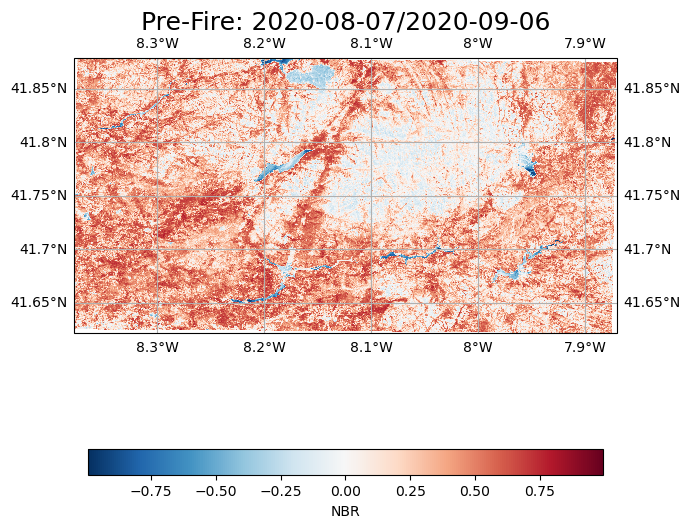

In [29]:
fig = plt.figure(1, figsize=[7, 10])

# We're using cartopy and are plotting in PlateCarree projection
# (see documentation on cartopy)
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines(resolution="10m")
ax.gridlines(draw_labels=True)

# We need to project our data to the new Orthographic projection and for this we use `transform`.
# we set the original data projection in transform (here Mercator)
prefire_burnratio.plot(
    ax=ax,
    transform=ccrs.epsg(prefire_burnratio.spatial_ref.values),
    cmap="RdBu_r",
    cbar_kwargs={"orientation": "horizontal", "shrink": 0.95},
)

# One way to customize your title
plt.title("Pre-Fire: " + time_range_start, fontsize=18)

## Plotting After

Text(0.5, 1.0, 'Post-Fire: 2020-09-20/2020-10-20')

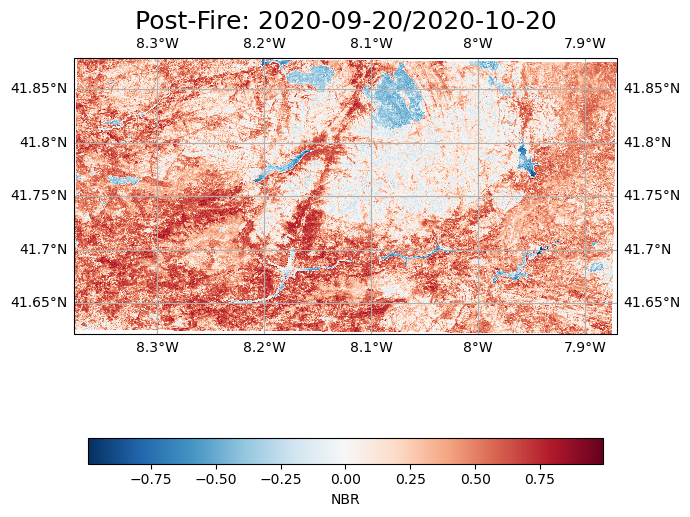

In [30]:
fig = plt.figure(1, figsize=[7, 9])

# We're using cartopy and are plotting in PlateCarree projection
# (see documentation on cartopy)
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines(resolution="10m")
ax.gridlines(draw_labels=True)

# We need to project our data to the new Orthographic projection and for this we use `transform`.
# we set the original data projection in transform (here Mercator)
postfire_burnratio.plot(
    ax=ax,
    transform=ccrs.epsg(postfire_burnratio.spatial_ref.values),
    cmap="RdBu_r",
    cbar_kwargs={"orientation": "horizontal", "shrink": 0.95},
)

# One way to customize your title
plt.title("Post-Fire: " + time_range_end, fontsize=18)

## Plotting Delta

The plot below highligths the burnt regions

Text(0.5, 1.0, 'Delta NBR')

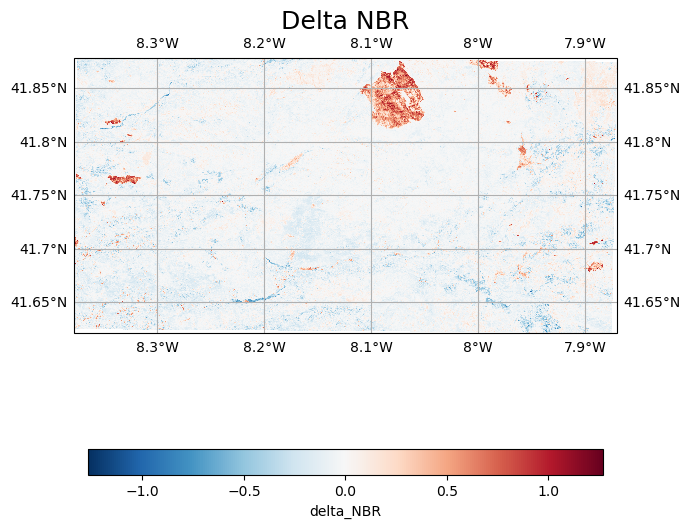

In [32]:
fig = plt.figure(1, figsize=[7, 10])

# We're using cartopy and are plotting in PlateCarree projection
# (see documentation on cartopy)
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines(resolution="10m")
ax.gridlines(draw_labels=True)

# We need to project our data to the new Orthographic projection and for this we use `transform`.
# we set the original data projection in transform (here Mercator)
dnbr_dataset.delta_NBR.plot(
    ax=ax,
    transform=ccrs.epsg(dnbr_dataset.delta_NBR.spatial_ref.values),
    cmap="RdBu_r",
    cbar_kwargs={"orientation": "horizontal", "shrink": 0.95},
)

# One way to customize your title
plt.title("Delta NBR", fontsize=18)

# Analysing Burnt Areas 

Great, now that we've calculated the delta NBR (dNBR), we can estimate the amount of area that was burned. First we need to classify which pixels are actually burned and then calculate the area that was burned.

To classify burned area we can use the dNBR reference ratio ratios described in: [https://un-spider.org/advisory-support/recommended-practices/recommended-practice-burn-severity/in-detail/normalized-burn-ratio](https://un-spider.org/advisory-support/recommended-practices/recommended-practice-burn-severity/in-detail/normalized-burn-ratio) - and estimate the moderate to severe burnt areas. **i.e. the areas with a dNBR of above 0.440**

![img](https://un-spider.org/sites/default/files/table+legend.PNG)

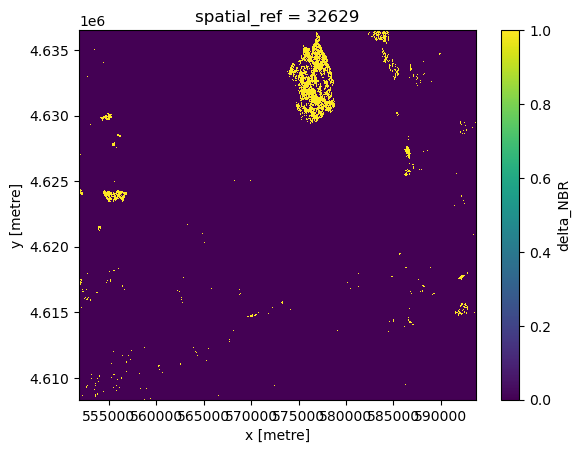

In [33]:
BURN_THRESH = 0.440
burn_mask = (
    dnbr_dataset.delta_NBR > BURN_THRESH
)  # True/False mask, same shape as raster
burn_mask.plot()

# save the burn_mask to our dataset
dnbr_dataset["burned_ha_mask"] = burn_mask

# Burned Area

Now with the above a data mask where all pixels classified as burnt are 1 and the non burnt ones are 0. To calculate burnt area, we simply sum all pixels and multiply them by the area which a pixel covers (i.e. the resolution, which in our case is 10m/p).

At the same step we will convert our metric to hectares (ha).

In [36]:
# dx, dy = dnbr_dataset.delta_NBR.rio.resolution()
dx = 10.0
dy = -10.0
pixel_area_ha = abs(dx * dy) / 1e4  # 10m × 10m = 0.01 ha

pixels_burned = burn_mask.sum().compute().item()  # integer number of burned pixels
burned_area_ha = pixels_burned * pixel_area_ha

print(f"Burned area   : {burned_area_ha:,.2f} ha")

Burned area   : 1,942.72 ha


# Saving Your Work

Now let's save our work! For intraoperability, we will save our data as a valid data cube in Zarr.

Keep in mind that EarthCODE provides different tooling that makes it easy to publish our data to the wider EO community on the EarthCODE Open Science Catalog (such as deep-code for publishing data cubes, we will see in the [**publishing guide**](../publishing-to-earthcode/deep-code/deep-code/publish-pangeo.ipynb)) by following common standards and using common file formats we ensure that there will be a tool to help us!


## Linting

There are also tools to ensure the quality of our data/metadata. Two very useful tools are `xrlint` which check our datarray against common expected standards and advise corrections (such as missing attributes which should be filled in). It's basically a linter for xarray - xarray + linter.


In [38]:
pip install xrlint

Note: you may need to restart the kernel to use updated packages.


In [41]:
linter = xrl.new_linter("recommended")
linter.validate(dnbr_dataset)

ds,warn,Missing attribute 'title'.,content-desc
ds,warn,Missing attribute 'history'.,content-desc
ds.data_vars['delta_NBR'],warn,Missing attribute 'institution'.,content-desc
ds.data_vars['delta_NBR'],warn,Missing attribute 'source'.,content-desc
ds.data_vars['delta_NBR'],warn,Missing attribute 'references'.,content-desc
ds.data_vars['delta_NBR'],warn,Missing attribute 'comment'.,content-desc
ds.data_vars['burned_ha_mask'],warn,Missing attribute 'institution'.,content-desc
ds.data_vars['burned_ha_mask'],warn,Missing attribute 'source'.,content-desc
ds.data_vars['burned_ha_mask'],warn,Missing attribute 'references'.,content-desc
ds.data_vars['burned_ha_mask'],warn,Missing attribute 'comment'.,content-desc
ds,warn,Missing attribute 'Conventions'.,conventions


### Add metadata descriptions to our data

As we see, there is quite a few attributes missing from our data cube. As a best practices, it's recommended to have it very well described, to ensure FAIR-ness and, specifically, intraoperability.

In [42]:
# Assign dataset-level attributes
dnbr_dataset.attrs.update(
    {
        "title": "Delta NBR and Burned Area Mask Dataset",
        "history": "Created by reprojecting and aligning datasets for fire severity analysis",
        "Conventions": "CF-1.7",
    }
)


# Assign variable-level attributes for delta_NBR
dnbr_dataset.delta_NBR.attrs.update(
    {
        "institution": "Lampata",
        "source": "Sentinel-2 imagery; processed with open-source dNBR code, element84...",
        "references": "https://registry.opendata.aws/sentinel-2-l2a-cogs/",
        "comment": "dNBR values represent change in vegetation severity post-fire",
        "standard_name": "difference_normalized_burn_ratio",
        "long_name": "Differenced Normalized Burn Ratio (dNBR)",
        "units": "m",
    }
)

# Example for burned_ha_mask data variable
dnbr_dataset.burned_ha_mask.attrs.update(
    {
        "standard_name": "burned_area_mask",
        "long_name": "Burned Area Mask in Hectares",
        "units": "hectares",
        "institution": "Your Institution Name",
        "source": "Derived from wildfire impact analysis",
        "references": "https://example.com/ref",
        "comment": "Burned area mask showing presence of burned areas",
    }
)

Great! Let's re-run the linter and see if we're missing anything.

## Data Cube Validation

Another useful tool is xcube's assert cube method which validates our data cube (e.g. dimensions, chunks, grids between dataarray's match and other checks - see more information at https://xcube.readthedocs.io/en/latest/cubespec.html#xcube-dataset-convention). Making sure we validate our data before saving or sharing will ensure that our data can be exploited by different, common EO libraries.

In [43]:
assert_cube(dnbr_dataset)  # raises ValueError if it's not xcube-valid

ValueError: Dataset is not a valid xcube dataset, because:
- missing time coordinate variable.

It seems like our data is not actually valid, as we missed timestamping our data burnt area final dataset! There's not really any information in the data to tell us when this wildfire event actually happened as well. Since deltaNBR highlights the burnt area after a fire, we will add the date of the postfire_ds to the dataset.

Simple checks like this help us avoid making simple mistakes, and catching/correcting these errors early on is  much easier than at a later stage. 

In [44]:
timestamp = np.datetime64(items[-1].properties["created"])

/tmp/ipykernel_534/786310608.py:3: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  timestamp = np.datetime64(items[-1].properties['created'])


In [45]:
# add time
dnbr_dataset = dnbr_dataset.expand_dims(time=[timestamp])

### Why is this important?

By ensuring your data follows common standards and FAIR principles, firstly and most importantly you enable make it usable by others and therefore increase its impact!

You also enable libraries that implement the common standards you follow to use your data. For example, for our dataset above, if we do not apply the corrections (for time specifically) any future applications using xcube won't be able to open up our dataset. Applications or users trying to understand how we derived our data will not have information, and etc...

The tools and standards help us along on the way to FAIR-ness!

## Saving and Chunking

To make our data easier to use for future users we will chunk it the recommended chunk sizes.

In [46]:
dnbr_dataset = dnbr_dataset.chunk({"time": 1, "y": 1000, "x": 1000}).load()
print(type(dnbr_dataset.burned_ha_mask.data))  # check data format

<class 'numpy.ndarray'>


Finally we create our local zarr store with .to_zarr. This will save the dataset locally.

*Note: You can easily store it on cloud storge such as s3 with some slight edits to the code below.*

In [47]:
save_at_folder = "./"
if not os.path.exists(save_at_folder):
    os.makedirs(save_at_folder)

# Define the output path within your notebook folder
output_path = os.path.join(save_at_folder, "dnbr_dataset.zarr")

# save
dnbr_dataset.to_zarr(output_path, mode="w")

# Conclusion

Congratulations! You've gotten to the end of this notebook. We explored a simple workflow with the [Pangeo](https://pangeo.io/) open-source software stack, demonstrated how to fetch and access EarthCODE published data and publically available Sentinel-2 data to generate burn severity maps for the assessment of the areas affected by wildfires. Finally, we saved our work and learned about why FAIRness matters.

As next steps we recommend reading through the documentation pages of each of the libraries, and going through the example in your own time in more detail! 

In [48]:
client.close()

# Links and Refernces

* https://www.sciencedirect.com/science/article/pii/S1470160X22004708#f0035
* https://github.com/yobimania/dea-notebooks/blob/e0ca59f437395f7c9becca74badcf8c49da6ee90/Fire%20Analysis%20Compiled%20Scripts%20(Gadi)/dNBR_full.py
* https://un-spider.org/advisory-support/recommended-practices/recommended-practice-burn-severity/in-detail/normalized-burn-ratio](https://un-spider.org/advisory-support/recommended-practices/recommended-practice-burn-severity/in-detail/normalized-burn-ratio
* https://github.com/bcdev/xrlint/tree/main/docs
* https://xcube.readthedocs.io/en/latest/
* https://docs.dask.org/en/stable/
* https://docs.xarray.dev/en/stable
* https://zarr.readthedocs.io/en/stable/
* https://corteva.github.io/rioxarray/stable/examples/reproject_match.html

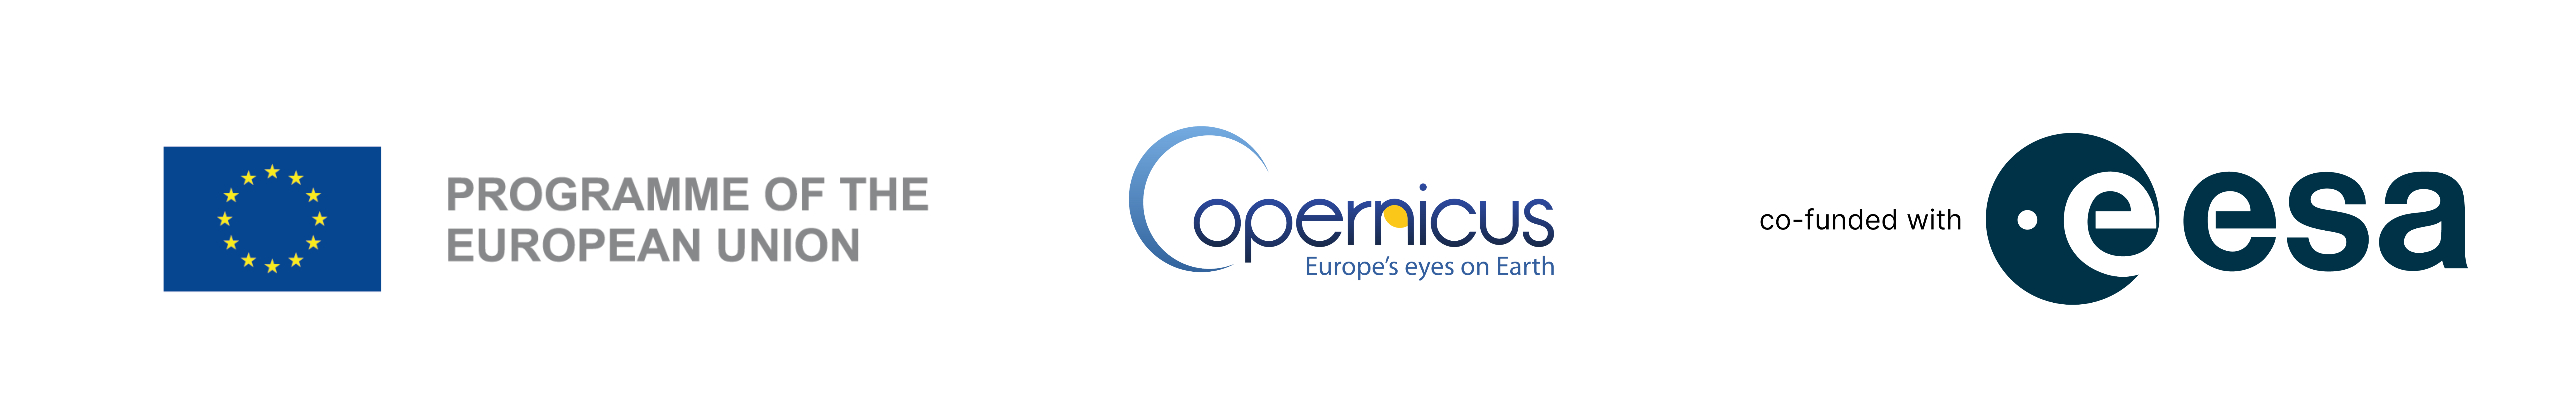